In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

from dpks import QuantMatrix
from dfmodel import DigitalFamilyBinary
from scanpy.experimental.pp import highly_variable_genes


In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [3]:
proteomics_data_train = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

In [4]:
#clinical_data_train = clinical_data_train[clinical_data_train['sepsis_or_septic_shock'] == 1.0]

In [5]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)

In [6]:
X, y = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))


In [7]:
quant_matrix_train.quantitative_data.var

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,sofa_coag_day1,sofa_coag_day2,sofa_coag_day3,sofa_cns_day1,sofa_cns_day2,sofa_cns_day3,sofa_liver_day1,sofa_liver_day2,sofa_liver_day3,sample
sample,,,,,,,,,,,,,,,,,,,,,
SA_BOX_1-462_S1-C8_1_6848,0,SA_BOX_1-462_S1-C8_1_6848,85.0,24.0,120.0,120.0,95.333333,1.0,39.5,73.0,...,1.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,SA_BOX_1-462_S1-C8_1_6848
SA_BOX_9-2606_S1-A5_1_6136,1,SA_BOX_9-2606_S1-A5_1_6136,75.0,30.0,117.0,134.0,107.333333,1.0,37.3,121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_9-2606_S1-A5_1_6136
SA_BOX_3-2442_S4-H8_1_5579,2,SA_BOX_3-2442_S4-H8_1_5579,94.0,48.0,125.0,120.0,NaN,1.0,39.9,66.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_3-2442_S4-H8_1_5579
SA_BOX_2-1644_S2-A10_1_6960,3,SA_BOX_2-1644_S2-A10_1_6960,80.0,35.0,94.0,113.0,75.666667,1.0,38.6,122.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_2-1644_S2-A10_1_6960
SA_BOX_4-2435_S5-E11_1_5698,4,SA_BOX_4-2435_S5-E11_1_5698,87.0,18.0,75.0,136.0,121.333333,1.0,35.6,107.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_4-2435_S5-E11_1_5698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SA_BOX_11-2056_S4-F8_1_6362,675,SA_BOX_11-2056_S4-F8_1_6362,96.0,40.0,95.0,110.0,80.000000,1.0,37.5,92.0,...,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN,SA_BOX_11-2056_S4-F8_1_6362
SA_BOX_3-697_S4-A6_1_5555,676,SA_BOX_3-697_S4-A6_1_5555,90.0,30.0,102.0,140.0,106.666667,1.0,39.0,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,SA_BOX_3-697_S4-A6_1_5555
SA_BOX_8-2367_S5-C12_1_6096,677,SA_BOX_8-2367_S5-C12_1_6096,74.0,40.0,100.0,133.0,97.666667,1.0,37.4,71.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SA_BOX_8-2367_S5-C12_1_6096


In [8]:
#X = X.loc[:, X.var() > X.var().median()]
protein_columns = X.columns.to_list()

In [9]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [10]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

clinical_data_train[continuous_clinical_columns] = clinical_imputer.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[["mental_status_ambulance"]] = constant_imputer.fit_transform(clinical_data_train[["mental_status_ambulance"]])

clinical_data_train[continuous_clinical_columns] = clinical_scaler.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[['sex']] = sex_scaler.fit_transform(clinical_data_train[['sex']])


In [12]:
clinical_data_train['resp_dysfunction'] =  np.where(
    clinical_data_train['sofa_resp_day1'] > 1, 1, np.where(
        clinical_data_train['sofa_resp_day2'] > 1, 1, np.where(
            clinical_data_train['sofa_resp_day3'] > 1, 1, 0
        )
    )
)

clinical_data_train['renal_dysfunction'] = np.where(
    clinical_data_train['sofa_renal_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_renal_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_renal_day2'] > 0, 1, 0
        )
    )
)

clinical_data_train['cardiovasc_dysfunction'] = np.where(
    clinical_data_train['sofa_cardiovasc_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_cardiovasc_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_cardiovasc_day3'] > 0, 1, 0
        )
    )

)

clinical_data_train['coag_dysfunction'] = np.where(
    clinical_data_train['sofa_coag_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_coag_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_coag_day3'] > 0, 1, 0
        )
    )
)

clinical_data_train['cns_dysfunction'] = np.where(
    clinical_data_train['sofa_cns_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_cns_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_cns_day3'] > 0, 1, 0
        )
    )
)

clinical_data_train['liver_dysfunction'] = np.where(
    clinical_data_train['sofa_liver_day1'] > 0, 1, np.where(
        clinical_data_train['sofa_liver_day2'] > 0, 1, np.where(
            clinical_data_train['sofa_liver_day3'] > 0, 1, 0
        )
    )
)

clinical_data_train['organ_dysfunction'] = np.where(
    clinical_data_train['sofa_score_increase_day1'] > 1, 1, np.where(
        clinical_data_train['sofa_score_increase_day2'] > 1, 1, np.where(
            clinical_data_train['sofa_score_increase_day3'] > 1, 1, 0
        )
    )
)

In [13]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis

resp_neighborhood = NeighborhoodComponentsAnalysis(
    n_components=1,
)
resp_components = resp_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["resp_dysfunction"])

renal_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
renal_components = renal_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["renal_dysfunction"])

cardiovasc_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
cardiovasc_components = cardiovasc_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["cardiovasc_dysfunction"])

coag_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
coag_components = coag_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["coag_dysfunction"])

cns_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
cns_components = cns_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["cns_dysfunction"])

liver_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
liver_components = liver_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["liver_dysfunction"])

In [14]:
component_normalizer = StandardScaler()

resp_components = pd.DataFrame(
    resp_components,
    columns=["resp1",]
)
renal_components = pd.DataFrame(
    renal_components,
    columns=["renal1",]
)
cardiovasc_components = pd.DataFrame(
    cardiovasc_components,
    columns=["car1",]
)
coag_components = pd.DataFrame(
    coag_components,
    columns=["coag1",]
)
cns_components = pd.DataFrame(
    cns_components,
    columns=["cns1",]
)
liver_components = pd.DataFrame(
    liver_components,
    columns=["liv1",]
)

components = pd.concat(
    [resp_components, renal_components, cardiovasc_components, coag_components, cns_components, liver_components],
    axis=1
)
component_cols = components.columns

In [15]:
components[component_cols] = component_normalizer.fit_transform(components[component_cols])

In [16]:
clinical_data_train[component_cols] = components[component_cols]

In [17]:
combined_columns = list(component_cols)#clinical_columns + list(component_cols)
combined_columns

['resp1', 'renal1', 'car1', 'coag1', 'cns1', 'liv1']

In [18]:
df_estimator = DigitalFamilyBinary(n_neighbors=10, neighbor_metric="euclidean", bootstrap_iterations=100)

In [19]:
df_estimator.fit(clinical_data_train, features=combined_columns)

In [20]:
clinical_data_train['Resp Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="resp_dysfunction", bootstrap=True)

clinical_data_train['Renal Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="renal_dysfunction", bootstrap=True)

clinical_data_train['Cardio Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="cardiovasc_dysfunction", bootstrap=True)

clinical_data_train['Liver Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="liver_dysfunction", bootstrap=True)

clinical_data_train['CNS Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="cns_dysfunction", bootstrap=True)

clinical_data_train['Coag Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="coag_dysfunction", bootstrap=True)

In [21]:
display_columns = [
    "Resp Rate",
    "Renal Rate",
    "Cardio Rate",
    "Liver Rate",
    "CNS Rate",
    "Coag Rate",
]

In [22]:
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

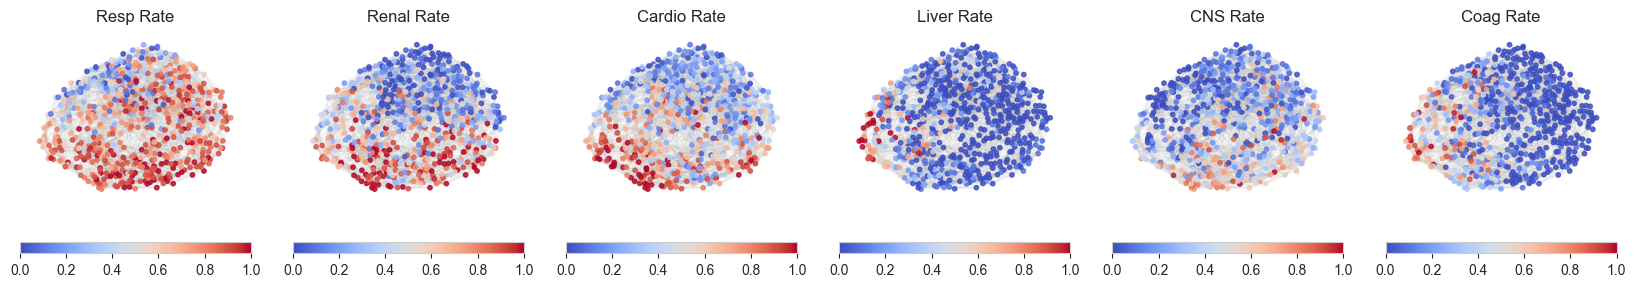

In [23]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=6
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(clinical_data_train[[col]])

    color_map = dict(zip(clinical_data_train.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27 * 2, 3))
plt.tight_layout()

In [24]:
fig.savefig(
    "organ_dysfunction_maps.pdf", dpi=300, bbox_inches="tight"
)

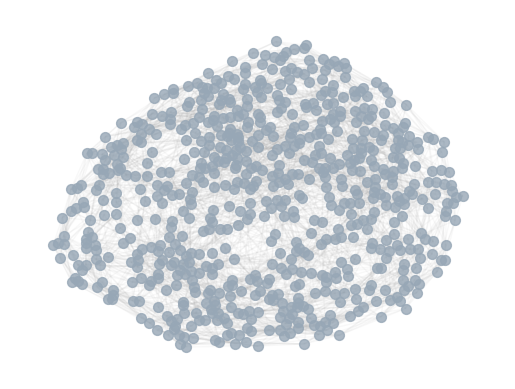

In [25]:
nx.draw_networkx_nodes(G, positions, node_size=50, node_color="#97A7B6", alpha=0.8)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05)
plt.axis('off')
plt.savefig(
    "overall_map.pdf", dpi=300, bbox_inches="tight"
)
plt.show()

<Axes: >

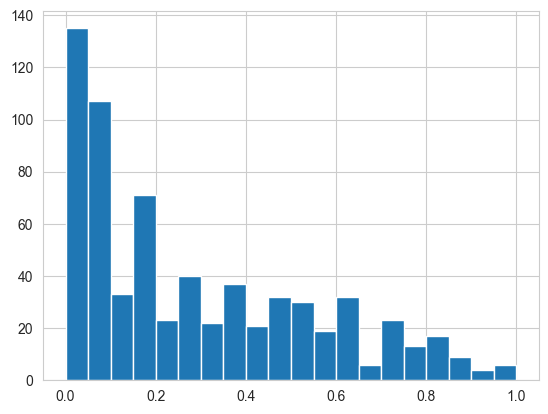

In [26]:
clinical_data_train['CNS Rate'].hist(bins=20)

In [27]:
clinical_data_train.to_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t",
    index=False
)

<Axes: >

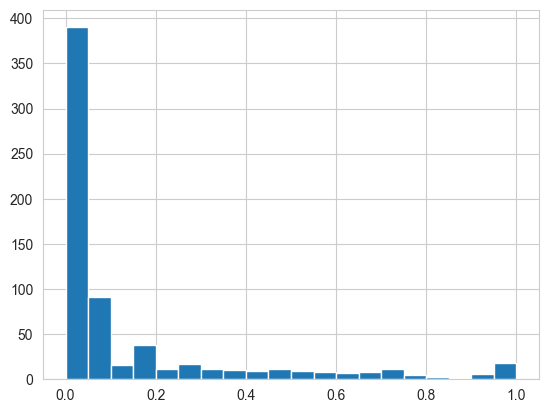

In [28]:
clinical_data_train['Liver Rate'].hist(bins=20)

In [29]:
resp_neighborhood

,n_components,1
,init,'auto'
,warm_start,False
,max_iter,50
,tol,1e-05
,callback,None
,verbose,0
,random_state,None


In [30]:
resp_weights = pd.DataFrame(
    {
        "Weight": np.abs(resp_neighborhood.components_.ravel()),
        "Feature": resp_neighborhood.feature_names_in_
    }
)
resp_weights

,Weight,Feature
0,0.381003,FIBA_HUMAN
1,0.033892,TRFE_HUMAN
2,0.553199,CFAH_HUMAN
3,0.276486,CERU_HUMAN
4,1.115159,GELS_HUMAN
...,...,...
282,0.171155,PTPRG_HUMAN
283,1.050993,FUCO_HUMAN
284,1.267105,LAMP2_HUMAN
285,2.068538,EIF3M_HUMAN


In [31]:
resp_weights.sort_values("Weight", ascending=False)

,Weight,Feature
40,5.506406,HGFA_HUMAN
184,5.187557,VASN_HUMAN
202,5.122524,CPN2_HUMAN
137,5.033553,SAA1_HUMAN
151,4.888303,APOF_HUMAN
...,...,...
76,0.034780,CFAB_HUMAN
1,0.033892,TRFE_HUMAN
142,0.033866,ALDOA_HUMAN
145,0.033429,TSP4_HUMAN


In [32]:
renal_weights = pd.DataFrame(
    {
        "Weight": np.abs(renal_neighborhood.components_.ravel()),
        "Feature": renal_neighborhood.feature_names_in_
    }
).sort_values("Weight", ascending=False)
renal_weights

,Weight,Feature
230,6.943433,CYTC_HUMAN
43,5.357336,FA5_HUMAN
217,5.348331,COIA1_HUMAN
22,5.121651,ANT3_HUMAN
146,4.903088,PTGDS_HUMAN
...,...,...
88,0.036069,PLSL_HUMAN
228,0.033635,APOC1_HUMAN
195,0.031901,FHR1_HUMAN
238,0.029750,CSPG2_HUMAN


In [33]:
liver_weights = pd.DataFrame(
    {
        "Weight": np.abs(liver_neighborhood.components_.ravel()),
        "Feature": liver_neighborhood.feature_names_in_
    }
).sort_values("Weight", ascending=False)
liver_weights

,Weight,Feature
7,3.796383,A2MG_HUMAN
178,3.274684,ITA2B_HUMAN
258,3.234522,TBB5_HUMAN
121,3.146453,ITIH3_HUMAN
118,2.909310,PON1_HUMAN
...,...,...
54,0.027043,VTNC_HUMAN
218,0.019437,APMAP_HUMAN
175,0.012444,CRIS3_HUMAN
233,0.004874,RS27A_HUMAN
